<div style="background: #d9004c; 
            padding: 25px; 
            border-radius: 15px; 
            text-align: center;
            box-shadow: 3px 3px 15px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Computer Graphics
    </h1>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Topic: Polygon Clipping
    </h3>
        <h3 style="font-family: 'Arial Black', sans-serif; color: white; margin-bottom: 10px;">
        Notebook by - Himel Sarder
    </h3>
    <p style="font-family: 'Verdana', sans-serif; color: #ffffffcc; font-size: 16px; text-align: center">
        info.himelcse@gmail.com
    </p>
</div>


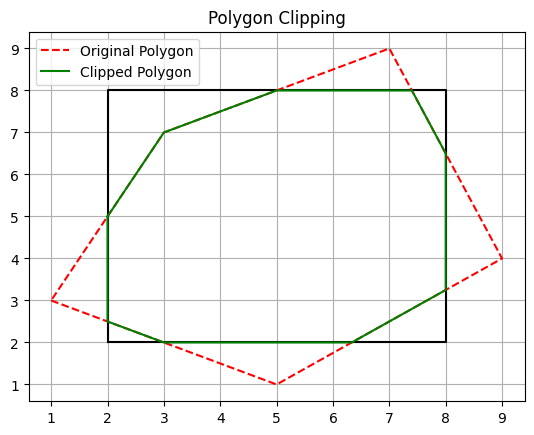

In [1]:
import matplotlib.pyplot as plt

# Clipping window
xmin, xmax = 2, 8
ymin, ymax = 2, 8

# Pentagon vertices
polygon = [(1, 3), (5, 1), (9, 4), (7, 9), (3, 7)]

# Example --> p = (1, 3)
# Window --> xmin = 2, xmax = 4, ymin = 2, ymax = 4

def inside(p, edge):  # L1: edge = left   L2: edge = right   L3: edge = bottom   L4: edge = top
    x, y = p          # x = 1, y = 3 

    if edge == "left":   
        # L1: Satisfied (edge = left)
        # Check --> x >= xmin
        # 1 >= 2 --> False → Outside
        return x >= xmin  

    elif edge == "right":  
        # L2: Satisfied (edge = right)
        # Check --> x <= xmax
        # 1 <= 4 --> True → Inside
        return x <= xmax   

    elif edge == "bottom":  
        # L3: Satisfied (edge = bottom)
        # Check --> y >= ymin
        # 3 >= 2 --> True → Inside

        # L1 & L2: Not satisfied → Skip
        return y >= ymin  

    elif edge == "top":   
        # L4: Satisfied (edge = top)
        # Check --> y <= ymax
        # 3 <= 4 --> True → Inside

        # L1, L2, L3: Not satisfied → Skip
        return y <= ymax  

def intersect(p1, p2, edge):
    x1, y1 = p1
    x2, y2 = p2

    if edge == "left":
        x = xmin
        y = y1 + (y2 - y1) * (xmin - x1) / (x2 - x1)
    elif edge == "right":
        x = xmax
        y = y1 + (y2 - y1) * (xmax - x1) / (x2 - x1)
    elif edge == "bottom":
        y = ymin
        x = x1 + (x2 - x1) * (ymin - y1) / (y2 - y1)
    elif edge == "top":
        y = ymax
        x = x1 + (x2 - x1) * (ymax - y1) / (y2 - y1)

    return (x, y)

def sutherland_hodgman(polygon):

    edges = ["left", "right", "bottom", "top"]
    # L1: edge = left
    # L2: edge = right
    # L3: edge = bottom
    # L4: edge = top


    output = polygon
    # Initially:
    # output = [(1,1), (5,1), (5,5), (1,5)]


    for edge in edges:

        input_list = output   # Clipped polygon used for next clipping
        # L1: input_list = original polygon
        # L2: input_list = left clipped polygon
        # L3: input_list = right clipped polygon
        # L4: input_list = bottom clipped polygon


        output = []
        # New polygon for current edge


        if not input_list:
            # If polygon becomes empty → stop
            break


        prev = input_list[-1]  # Work pair wise
        # Take the last point as the previous
        # Example → prev = (1,5)


        for curr in input_list:

            # curr = current point
            # Example flow:
            # (1,5) → (1,1) → (5,1) → (5,5) → (1,5)


            if inside(curr, edge):

                if inside(prev, edge):
                    # CASE 1: prev inside, curr inside

                    # L1 Example:
                    # prev=(5,1), curr=(5,5) → both inside (left edge)
                    # → only curr add

                    output.append(curr)


                else:
                    # CASE 2: prev outside, curr inside

                    # L1 Example:
                    # prev=(1,1) ❌ outside
                    # curr=(5,1) ✅ inside

                    # Step 1: intersection add
                    # Step 2: curr add

                    output.append(intersect(prev, curr, edge))
                    output.append(curr)


            elif inside(prev, edge):
                # CASE 3: prev inside, curr outside

                # L1 Example:
                # prev=(5,5) ✅ inside
                # curr=(1,5) ❌ outside

                # শুধু intersection add

                output.append(intersect(prev, curr, edge))


            # CASE 4: prev outside, curr outside
            # → Nothing will append!


            prev = curr
            # Move forward (very important)
            # next iteration এ curr → prev হবে


    return output

# Perform clipping
clipped = sutherland_hodgman(polygon)

# Plotting
plt.figure()
plt.title("Polygon Clipping")

# Clipping window
plt.plot([xmin, xmax, xmax, xmin, xmin],
         [ymin, ymin, ymax, ymax, ymin], 'k-')

# Original pentagon
x, y = zip(*(polygon + [polygon[0]]))
plt.plot(x, y, 'r--', label='Original Polygon')

# Clipped pentagon
if clipped:
    xc, yc = zip(*(clipped + [clipped[0]]))
    plt.plot(xc, yc, 'g-', label='Clipped Polygon')

plt.legend()
plt.grid()
plt.show()